# Linear Support Vector Machine on the Breast Cancer Dataset

This notebook demonstrates the `LinearSVM` classifier implemented in the `jiayi_ml` package.

The goal is to classify breast tumor samples as malignant or benign using numeric features computed from digitized images of breast mass cell nuclei.

This example emphasizes:

1. Binary classification.
2. Margin-based learning.
3. Hinge loss.
4. Linear decision boundaries.
5. L2 regularization.
6. Confusion matrix interpretation.
7. Decision score analysis.
8. Limitations of linear SVMs compared with kernel SVMs.


## 1. Problem Statement

The Breast Cancer Wisconsin dataset is a binary classification dataset.

Each sample describes a breast tumor using numeric measurements derived from cell nuclei. The original target labels are:

- `malignant`
- `benign`

For this notebook, the target is recoded so that:

- `1` = malignant
- `0` = benign

This makes malignant tumors the positive class.

The prediction task is:

> Given numeric tumor measurements, predict whether a tumor sample is malignant or benign.

This is a supervised binary classification problem.

This notebook is an educational machine learning example. It should not be interpreted as a clinical diagnostic tool.


## Modeling Hypothesis

A linear support vector machine should perform well on this dataset because many breast cancer features show strong separation between malignant and benign samples.

The main hypothesis is:

> If the standardized features provide a roughly linearly separable representation of the two classes, then a linear SVM should achieve strong test-set classification performance by learning a maximum-margin separating hyperplane.

However, the model may still make errors because some benign and malignant samples overlap in feature space, the decision boundary is linear, and the selected regularization strength affects the margin-error trade-off.


## 2. Modeling Hypothesis

A linear support vector machine should perform well on this dataset because many breast cancer features show strong separation between malignant and benign samples.

The main hypothesis is:

> If the standardized features provide a roughly linearly separable representation of the two classes, then a linear SVM should achieve strong test-set classification performance by learning a maximum-margin separating hyperplane.

However, the model may still make errors because:

- some benign and malignant samples overlap in feature space,
- the decision boundary is linear,
- the dataset is a classic benchmark and may not represent external clinical data,
- the selected regularization strength affects the margin and error trade-off.


In [1]:
from pathlib import Path
import sys

# Make the local package importable whether the notebook is run from the
# project root or from inside the examples directory.
current_path = Path.cwd().resolve()
for candidate in [current_path, *current_path.parents]:
    if (candidate / "src" / "jiayi_ml").exists():
        sys.path.insert(0, str(candidate / "src"))
        PROJECT_ROOT = candidate
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from jiayi_ml.preprocessing import StandardScaler
from jiayi_ml.supervised import LinearSVM
from jiayi_ml.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

np.random.seed(438)
pd.set_option("display.precision", 4)


## 3. Load the Dataset

The dataset is loaded from `sklearn.datasets.load_breast_cancer`, so the notebook is reproducible without external files.

The original sklearn target encoding is:

- `0` = malignant
- `1` = benign

This notebook recodes the target so that malignant is the positive class.


In [2]:
data = load_breast_cancer(as_frame=True)

X = data.data
y_original = data.target
feature_names = X.columns.tolist()
target_names = data.target_names

# Recode target:
# original 0 = malignant, original 1 = benign
# new 1 = malignant, new 0 = benign
y = (y_original == 0).astype(int)

df = X.copy()
df["malignant"] = y

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Original target names:", target_names)
print("Number of features:", len(feature_names))

df.head()


Feature matrix shape: (569, 30)
Target shape: (569,)
Original target names: ['malignant' 'benign']
Number of features: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,1
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,1
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,1
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,1
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,1


## 4. Exploratory Data Analysis

Before fitting the SVM, we inspect:

- missing values,
- class balance,
- feature ranges,
- correlations with the malignant indicator.

Class balance matters because accuracy alone can be misleading when one class is much more common than the other.

Feature scale matters because a linear SVM uses dot products and margin distances. Standardization is therefore important.


In [3]:
missing_values = df.isna().sum()

print("Total missing values:", int(missing_values.sum()))

summary = X.describe().T
summary.head(12)


Total missing values: 0


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
mean texture,569.0,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
mean perimeter,569.0,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
mean area,569.0,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
mean smoothness,569.0,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
mean compactness,569.0,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
mean concavity,569.0,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
mean concave points,569.0,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
mean symmetry,569.0,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040
mean fractal dimension,569.0,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974


In [4]:
class_counts = pd.Series(y).value_counts().sort_index()
class_counts.index = ["benign (0)", "malignant (1)"]

class_counts_df = class_counts.to_frame(name="count")
class_counts_df["proportion"] = class_counts_df["count"] / class_counts_df["count"].sum()
class_counts_df


,count,proportion
benign (0),357,0.6274
malignant (1),212,0.3726


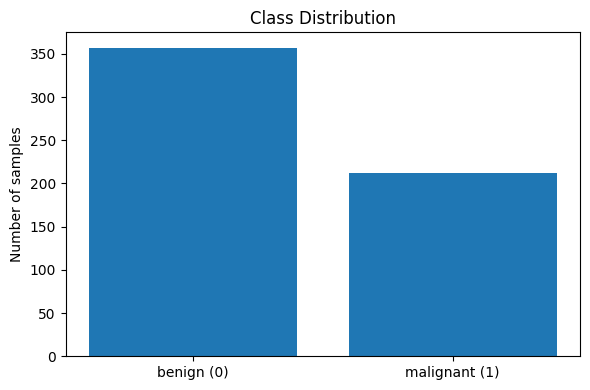

In [5]:
plt.figure(figsize=(6, 4))
plt.bar(class_counts_df.index, class_counts_df["count"])
plt.ylabel("Number of samples")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()


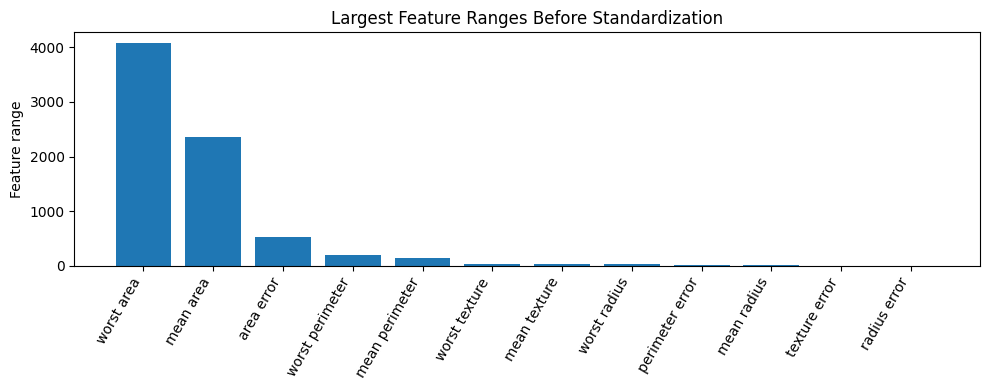

,range
worst area,4068.8000
mean area,2357.5000
area error,535.3980
worst perimeter,200.7900
mean perimeter,144.7100
worst texture,37.5200
mean texture,29.5700
worst radius,28.1100
perimeter error,21.2230
mean radius,21.1290


In [6]:
feature_ranges = (X.max() - X.min()).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(feature_ranges.index[:12], feature_ranges.values[:12])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Feature range")
plt.title("Largest Feature Ranges Before Standardization")
plt.tight_layout()
plt.show()

feature_ranges.head(12).to_frame(name="range")


The feature ranges differ substantially, which supports the decision to standardize the data before fitting the SVM.


In [7]:
correlations = df.corr(numeric_only=True)["malignant"].drop("malignant")
top_correlations = correlations.reindex(
    correlations.abs().sort_values(ascending=False).index
).head(12)

top_correlations_df = top_correlations.to_frame(name="correlation_with_malignant")
top_correlations_df


,correlation_with_malignant
worst concave points,0.7936
worst perimeter,0.7829
mean concave points,0.7766
worst radius,0.7765
mean perimeter,0.7426
worst area,0.7338
mean radius,0.7300
mean area,0.7090
mean concavity,0.6964
worst concavity,0.6596


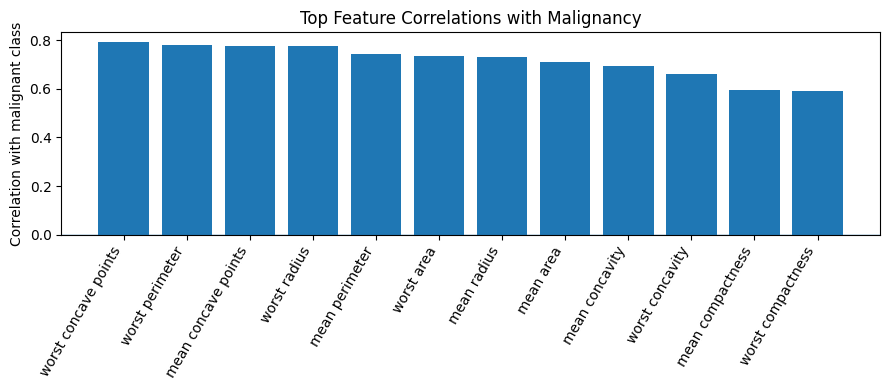

In [8]:
plt.figure(figsize=(9, 4))
plt.bar(top_correlations.index, top_correlations.values)
plt.axhline(0, linewidth=1)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Correlation with malignant class")
plt.title("Top Feature Correlations with Malignancy")
plt.tight_layout()
plt.show()


The correlation analysis suggests that several features are strongly associated with the malignant class. This supports the modeling hypothesis that a linear classifier may be effective.

This is not a causal interpretation. Correlation only describes association in this dataset.


## 5. Train/Test Split and Standardization

The data is split into training and test sets using stratification so that class proportions are preserved.

The scaler is fit only on the training data and then applied to the test data. This avoids data leakage.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.25,
    random_state=438,
    stratify=y.values,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)
print("Training class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))


Training set shape: (426, 30)
Test set shape: (143, 30)
Training class counts: [267 159]
Test class counts: [90 53]


## 6. Fit the Custom Linear SVM

The model below uses the custom `LinearSVM` implementation from the local `jiayi_ml` package.

This implementation optimizes a soft-margin linear SVM objective using hinge loss and L2 regularization.

The regularization strength `alpha` controls the trade-off between margin size and weight shrinkage.


In [10]:
model = LinearSVM(
    learning_rate=0.01,
    max_iter=10000,
    alpha=0.01,
    fit_intercept=True,
    tol=1e-8,
)

model.fit(X_train_scaled, y_train)

print("Number of iterations:", model.n_iter_)
print("Final objective value:", model.losses_[-1])
print("Coefficient shape:", model.coef_.shape)
print("Intercept:", model.intercept_)


Number of iterations: 1110
Final objective value: 0.07867743383000338
Coefficient shape: (30,)
Intercept: -0.08575745011906381


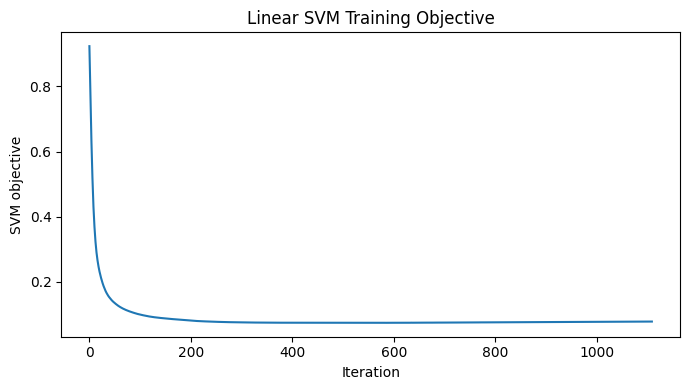

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(model.losses_)
plt.xlabel("Iteration")
plt.ylabel("SVM objective")
plt.title("Linear SVM Training Objective")
plt.tight_layout()
plt.show()


The training objective decreases as the model updates its coefficients. This provides a basic check that gradient descent is optimizing the hinge-loss objective.


## 7. Test-Set Evaluation

The linear SVM predicts the class based on the sign of its decision score.

A positive score corresponds to the malignant class, and a negative score corresponds to the benign class.

We evaluate the model using:

- Accuracy
- Precision for malignant class
- Recall for malignant class
- F1 score for malignant class
- Confusion matrix


In [12]:
y_pred = model.predict(X_test_scaled)
decision_scores = model.decision_function(X_test_scaled)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_malignant": precision_score(y_test, y_pred, pos_label=1),
    "recall_malignant": recall_score(y_test, y_pred, pos_label=1),
    "f1_malignant": f1_score(y_test, y_pred, pos_label=1),
}

metrics_df = pd.DataFrame(metrics, index=["Linear SVM"]).T
metrics_df


,Linear SVM
accuracy,1.0
precision_malignant,1.0
recall_malignant,1.0
f1_malignant,1.0


In [13]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["true benign", "true malignant"],
    columns=["predicted benign", "predicted malignant"],
)

cm_df


,predicted benign,predicted malignant
true benign,90,0
true malignant,0,53


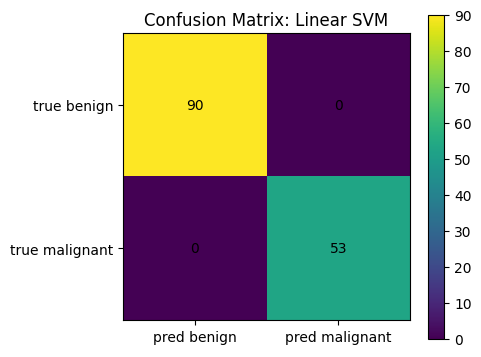

In [14]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.xticks([0, 1], ["pred benign", "pred malignant"])
plt.yticks([0, 1], ["true benign", "true malignant"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.title("Confusion Matrix: Linear SVM")
plt.colorbar()
plt.tight_layout()
plt.show()


The confusion matrix separates the two main error types:

- False positive: a benign sample predicted as malignant.
- False negative: a malignant sample predicted as benign.

In a screening-oriented health example, false negatives are especially important because they represent missed malignant cases. This is why recall for the malignant class should be interpreted alongside accuracy.

In this particular train/test split, the linear SVM achieves perfect test-set performance. This result should be interpreted cautiously.

A perfect score on one held-out split does not mean that the model would generalize perfectly to new clinical data. The Breast Cancer dataset is a classic benchmark dataset with strong feature separation, and this specific random split appears especially clean. The result supports the modeling hypothesis that a linear margin-based classifier is effective on this dataset, but a more rigorous evaluation would require repeated train/test splits, cross-validation, calibration analysis, and external validation.


## 8. Decision Score Analysis

Unlike logistic regression, this simple linear SVM implementation does not produce calibrated probabilities.

Instead, it produces decision scores:

- Larger positive scores indicate stronger classification as malignant.
- Larger negative scores indicate stronger classification as benign.
- Scores near zero are closer to the decision boundary and are more uncertain.


In [15]:
score_df = pd.DataFrame(
    {
        "decision_score": decision_scores,
        "true_label": y_test,
        "predicted_label": y_pred,
    }
)

score_df["true_label_name"] = score_df["true_label"].map({0: "benign", 1: "malignant"})
score_df["correct"] = score_df["true_label"] == score_df["predicted_label"]

score_df.head()


,decision_score,true_label,predicted_label,true_label_name,correct
0,-5.0840,0,0,benign,True
1,-3.8042,0,0,benign,True
2,-4.4390,0,0,benign,True
3,-6.7872,0,0,benign,True
4,-0.9004,0,0,benign,True


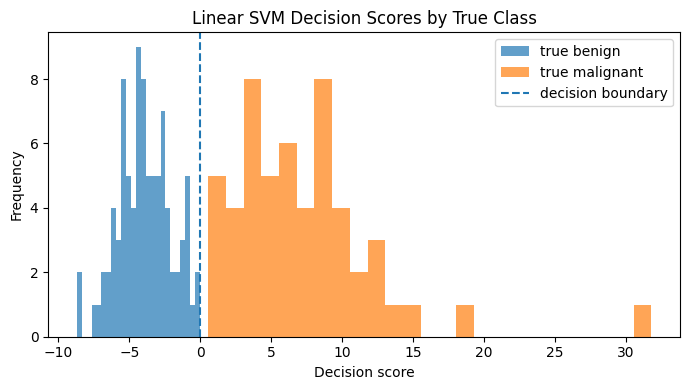

In [16]:
plt.figure(figsize=(7, 4))
plt.hist(
    score_df.loc[score_df["true_label"] == 0, "decision_score"],
    bins=25,
    alpha=0.7,
    label="true benign",
)
plt.hist(
    score_df.loc[score_df["true_label"] == 1, "decision_score"],
    bins=25,
    alpha=0.7,
    label="true malignant",
)
plt.axvline(0, linestyle="--", label="decision boundary")
plt.xlabel("Decision score")
plt.ylabel("Frequency")
plt.title("Linear SVM Decision Scores by True Class")
plt.legend()
plt.tight_layout()
plt.show()


The decision score distribution shows how far samples are from the separating hyperplane. Samples near zero are closer to the decision boundary and are more likely to be ambiguous.


## 9. Regularization Sensitivity

The regularization parameter affects the learned margin and coefficient size.

Smaller `alpha` values allow larger coefficients and a more flexible separating boundary. Larger `alpha` values shrink coefficients more strongly and may underfit if the penalty is too strong.


In [17]:
alpha_values = [0.001, 0.01, 0.1, 1.0]
alpha_results = []

for alpha in alpha_values:
    svm = LinearSVM(
        learning_rate=0.01,
        max_iter=10000,
        alpha=alpha,
        fit_intercept=True,
        tol=1e-8,
    )
    svm.fit(X_train_scaled, y_train)
    pred = svm.predict(X_test_scaled)
    cm_alpha = confusion_matrix(y_test, pred, labels=[0, 1])
    
    alpha_results.append(
        {
            "alpha": alpha,
            "accuracy": accuracy_score(y_test, pred),
            "precision_malignant": precision_score(y_test, pred, pos_label=1),
            "recall_malignant": recall_score(y_test, pred, pos_label=1),
            "f1_malignant": f1_score(y_test, pred, pos_label=1),
            "false_positives": cm_alpha[0, 1],
            "false_negatives": cm_alpha[1, 0],
            "coef_norm": np.linalg.norm(svm.coef_),
            "n_iter": svm.n_iter_,
        }
    )

alpha_results_df = pd.DataFrame(alpha_results)
alpha_results_df


,alpha,accuracy,precision_malignant,recall_malignant,f1_malignant,false_positives,false_negatives,coef_norm,n_iter
0,0.001,1.000,1.0,1.0000,1.0000,0,0,1.9544,658
1,0.010,1.000,1.0,1.0000,1.0000,0,0,2.2431,1110
2,0.100,1.000,1.0,1.0000,1.0000,0,0,1.7384,3620
3,1.000,0.979,1.0,0.9434,0.9709,0,3,0.6806,2522


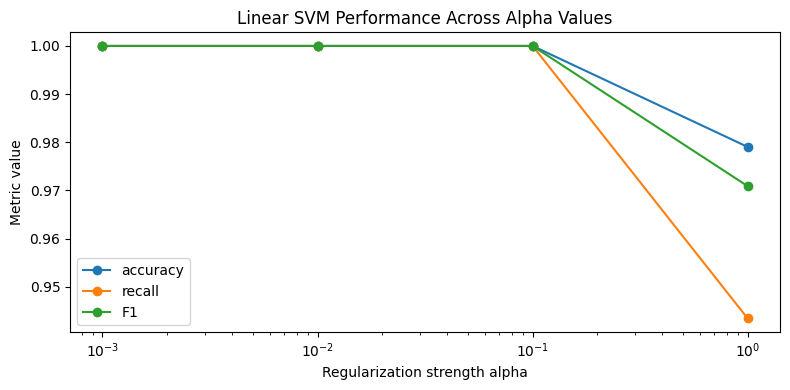

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(alpha_results_df["alpha"], alpha_results_df["accuracy"], marker="o", label="accuracy")
plt.plot(alpha_results_df["alpha"], alpha_results_df["recall_malignant"], marker="o", label="recall")
plt.plot(alpha_results_df["alpha"], alpha_results_df["f1_malignant"], marker="o", label="F1")
plt.xscale("log")
plt.xlabel("Regularization strength alpha")
plt.ylabel("Metric value")
plt.title("Linear SVM Performance Across Alpha Values")
plt.legend()
plt.tight_layout()
plt.show()


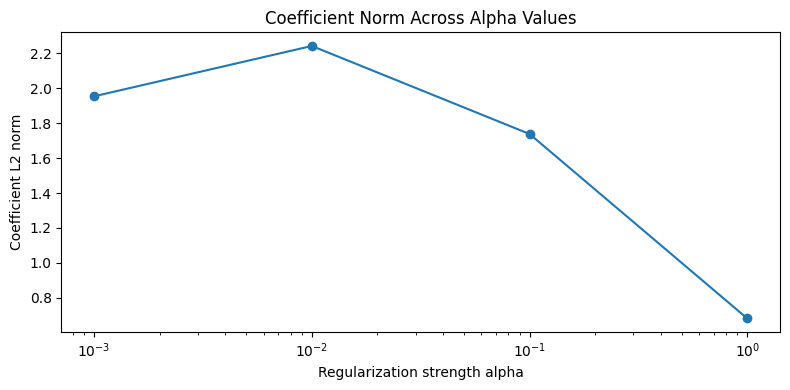

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(alpha_results_df["alpha"], alpha_results_df["coef_norm"], marker="o")
plt.xscale("log")
plt.xlabel("Regularization strength alpha")
plt.ylabel("Coefficient L2 norm")
plt.title("Coefficient Norm Across Alpha Values")
plt.tight_layout()
plt.show()


The regularization sensitivity analysis shows that the model is stable for small to moderate regularization values. For `alpha = 0.001`, `0.01`, and `0.1`, the model achieves perfect test-set metrics under this split.

When `alpha = 1.0`, performance decreases: recall for the malignant class drops and the model produces false negatives. This suggests that excessive regularization can shrink the coefficients too strongly and move the decision boundary in a way that misses some malignant samples.

This supports the general margin-regularization trade-off in linear SVMs: regularization can improve stability, but too much regularization can underfit.


## 10. Coefficient Inspection

Because this is a linear model, we can inspect the learned coefficients.

The coefficients are based on standardized features, so their magnitudes are more comparable than they would be on raw features.

Positive coefficients increase the decision score toward the malignant class. Negative coefficients decrease the score toward the benign class.


In [20]:
coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": model.coef_,
        "abs_coefficient": np.abs(model.coef_),
    }
).sort_values("abs_coefficient", ascending=False)

coef_df.head(12)


,feature,coefficient,abs_coefficient
21,worst texture,0.6490,0.6490
10,radius error,0.6179,0.6179
28,worst symmetry,0.6163,0.6163
15,compactness error,-0.6138,0.6138
6,mean concavity,0.5592,0.5592
23,worst area,0.5347,0.5347
13,area error,0.5330,0.5330
29,worst fractal dimension,0.5163,0.5163
20,worst radius,0.5110,0.5110
7,mean concave points,0.5031,0.5031


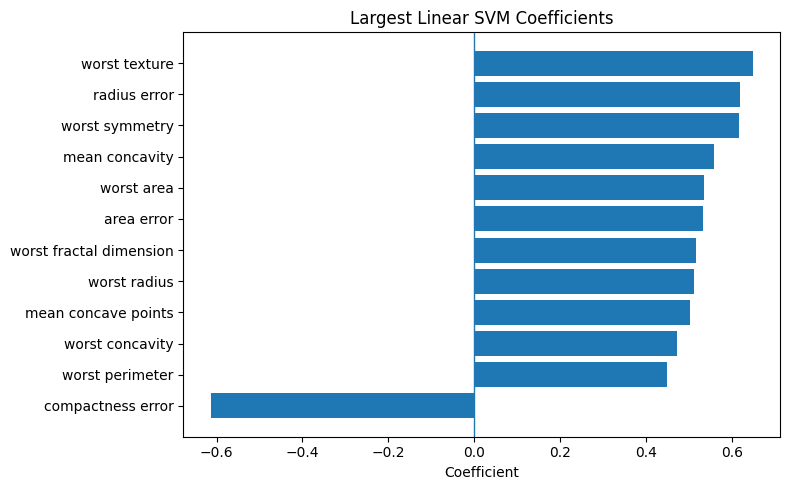

In [21]:
top_coef = coef_df.head(12).sort_values("coefficient")

plt.figure(figsize=(8, 5))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.axvline(0, linewidth=1)
plt.xlabel("Coefficient")
plt.title("Largest Linear SVM Coefficients")
plt.tight_layout()
plt.show()


Coefficient inspection helps explain the model's decision rule. However, coefficients should be interpreted cautiously because many breast cancer features are correlated. A large coefficient reflects model behavior, not causal importance.


## 11. Linear SVM vs. Kernel SVM

This implementation is a linear SVM. It learns a linear decision boundary in the input feature space.

A kernel SVM can learn nonlinear boundaries by implicitly mapping data into a higher-dimensional feature space. Kernel SVMs are more flexible but require additional design choices such as the kernel type and kernel parameters.

For this dataset, a linear SVM is a reasonable baseline because the features are already informative and show strong class separation.


## 12. Limitations

This analysis has several limitations:

1. The dataset is a classic benchmark dataset and may be easier than external clinical data.
2. The model is linear and may miss nonlinear structure.
3. This implementation does not include kernel functions.
4. This implementation does not provide calibrated probabilities.
5. Hyperparameters were explored only over a small grid.
6. The result is based on one train/test split rather than repeated cross-validation.
7. Coefficient interpretation is affected by correlated features.
8. This is an educational example, not a clinical diagnostic system.

A stronger analysis could include repeated train/test splits, cross-validation, calibration, external validation, and comparison with kernel SVMs or other nonlinear models.


## 13. Conclusion

This notebook demonstrated a linear support vector machine using the custom `LinearSVM` implementation from `jiayi_ml`.

Key takeaways:

- Linear SVM is a margin-based binary classifier.
- Hinge loss penalizes samples that are misclassified or too close to the margin.
- Standardization is important for SVMs.
- Decision scores indicate distance-like confidence relative to the separating hyperplane.
- Regularization affects coefficient size and model flexibility.
- Linear SVM is useful as an interpretable margin-based baseline, but it is less flexible than kernel SVM.
